In [40]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables

Note: you may need to restart the kernel to use updated packages.


In [41]:
import polars as pl
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from collections import defaultdict
from dataclasses import dataclass
from enum import Enum

# Utilities

In [42]:
schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})

class Library(Enum):
    libfabric = "libfabric"
    native = "native"

class Format(Enum):
    _720= "720"
    _1080= "1080"
    _2160= "2160"

class Completion(Enum):
    spin = "Spin"
    wait = "Wait"
    none = ""
    
class Transport(Enum):
    tcp = "Tcp"
    verbs = "Verbs"
    shm = "SHM"
    none = ""

class TransferMode(Enum):
    oneway = "OneWay"
    reflect = "Reflect"
    none = ""

class Movement(Enum):
    d2d = "Cuda2Cuda"
    dh2hd = "Cuda2Host2Host2Cuda"
    h2d = "Host2Cuda"
    d2h = "Cuda2Host"
    
class Test(Enum):
    mxl_fabrics="MXLFabrics"
    native_cuda="NativeCuda"

@dataclass(frozen=True, eq=True)
class TestConfiguration:
    library: Library
    format: Format
    completion: Completion
    test: Test
    movement: Movement
    transport: Transport
    tx_mode: TransferMode

def get_mxlfabrics_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}+{conf.transport.value}+{conf.tx_mode.value}+{conf.completion.value}"

def get_nativecuda_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}"

def diff_loader(data):
    return data["RxTime"] - data["TxTime"]

def timers_loader(data):
    return data["Timers"]

def load_data(directory, loader,libraries=Library, formats=Format, completions=Completion, tests=Test, movements=Movement,  transports=Transport, tx_modes=TransferMode):
    data = {}
    for format in formats:
        for movement in movements:
            for tx_mode in tx_modes:
                for test in tests:
                    if test == Test.mxl_fabrics:
                        for library in libraries:
                            for comp in completions:
                                for transport in transports:
                                    test_conf = TestConfiguration(library, format, comp, test, movement, transport, tx_mode)
                                    data[test_conf] = loader(pl.read_csv(f"{directory}/{format.value}/{library.value}/{get_mxlfabrics_test_name(test_conf)}.csv", schema=schema))
                    elif test == Test.native_cuda:
                        library = Library.native
                        test_conf = TestConfiguration(library, format, Completion.none, test, movement, Transport.none, TransferMode.none)
                        data[test_conf] = timers_loader(pl.read_csv(f"{directory}/{format.value}/{library.value}/{get_nativecuda_test_name(test_conf)}.csv", schema=schema))
    return data

def make_table(data, columns):
    table_data = defaultdict(list)    
    for test_conf, values in data.items():
        for col in columns:
            table_data[col].append(getattr(test_conf, col))
        
        table_data["mean"].append(round(values.mean()/1e6,4))
        table_data["max"].append(round(values.max()/1e6,4))
        table_data["std"].append(round(values.std()/1e6,4))
                                   
    return GT(pl.DataFrame(table_data))


# Setup

In [43]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]

# Transfers

## Device to Device Inter-Host

In [44]:
kwargs = {"tests": [Test.mxl_fabrics], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data_d2d_interhost = load_data(f"../data/d2d-interhost", timers_loader, **kwargs)

### Comparison libfabric vs native for Device to Device Inter-Host transfers

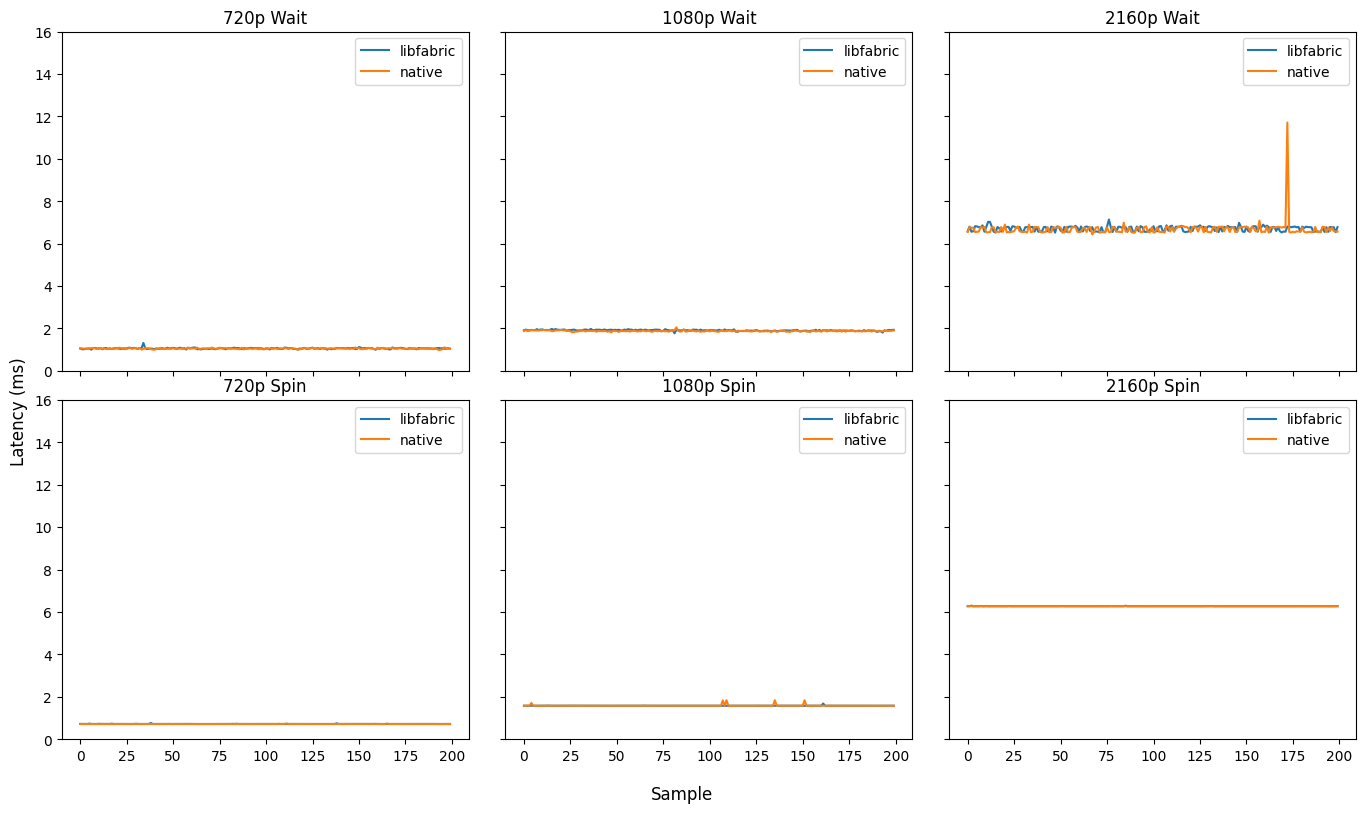

In [45]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(kwargs["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(kwargs["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in Library:
            axs[j][i].plot(data_d2d_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{library.value}")
            axs[j][i].legend()

In [46]:
columns = ["library","format", "completion"]
d2d_interhost_table = make_table(data_d2d_interhost, columns=columns)

d2d_interhost_table
(
    d2d_interhost_table
    .tab_header(
        title="Device-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=columns
    )
    .tab_spanner(
        label="Latency Measurements (ms)",
        columns=["mean", "max", "std"]
    )
    .tab_style(
        style.fill("red"),
        loc.body(
            columns = pl.selectors.all(),
            rows = pl.col("max") == pl.col("max").max()
        )
    )
)

GT(_tbl_data=shape: (12, 6)
┌───────────┬────────┬────────────┬────────┬─────────┬────────┐
│ library   ┆ format ┆ completion ┆ mean   ┆ max     ┆ std    │
│ ---       ┆ ---    ┆ ---        ┆ ---    ┆ ---     ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ f64    ┆ f64     ┆ f64    │
╞═══════════╪════════╪════════════╪════════╪═════════╪════════╡
│ libfabric ┆ 720    ┆ Wait       ┆ 1.0586 ┆ 1.3203  ┆ 0.0291 │
│ libfabric ┆ 720    ┆ Spin       ┆ 0.7228 ┆ 0.7687  ┆ 0.0045 │
│ native    ┆ 720    ┆ Wait       ┆ 1.0527 ┆ 1.1107  ┆ 0.0207 │
│ native    ┆ 720    ┆ Spin       ┆ 0.7204 ┆ 0.7434  ┆ 0.0025 │
│ libfabric ┆ 1080   ┆ Wait       ┆ 1.9118 ┆ 1.9798  ┆ 0.029  │
│ …         ┆ …      ┆ …          ┆ …      ┆ …       ┆ …      │
│ native    ┆ 1080   ┆ Spin       ┆ 1.5866 ┆ 1.8426  ┆ 0.0375 │
│ libfabric ┆ 2160   ┆ Wait       ┆ 6.7121 ┆ 7.1362  ┆ 0.1204 │
│ libfabric ┆ 2160   ┆ Spin       ┆ 6.2744 ┆ 6.2993  ┆ 0.0027 │
│ native    ┆ 2160   ┆ Wait       ┆ 6.6834 ┆ 11.7068 ┆ 0.377  │
│ native    ┆ 2160   ┆ Spin       ┆ 6.273  ┆ 6.28    ┆ 0.0007 │
└───────────┴────────┴────────────┴────────┴─────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x78cc6c12bcd0>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x78cc64483c50>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion'], built=None), SpannerInfo(spanner_id='Latency Measurements (ms)', spanner_level=0, spanner_label='Latency Measurements (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='library', rownum=10, colnum=None, styles=[CellStyleFill(color='red')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='format', rownum=10, colnum=None, styles=[CellStyleFill(color='red')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='completion', rownum=10, colnum=None, styles=[CellStyleFill(color='red')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='mean', rownum=10, colnum=None, styles=[CellStyleFill(color='red')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='max', rownum=10, colnum=None, styles=[CellStyleFill(color='red')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("max")) == (col("max").m…'] at 0x78CC643A5BD0>, mask=None), grpname=None, colname='std', rownum=10, colnum=None, styles=[CellStyleFill(color='red')])], _locale=<great_tables._gt_data.Locale object at 0x78cc6c708290>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=

## Device to Host 2 Host to Device Inter-host

In [47]:
kwargs = {"tests": [Test.mxl_fabrics], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}

# load data
data_dh2hd_interhost = load_data(f"../data/dh2hd-interhost", timers_loader, **kwargs)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

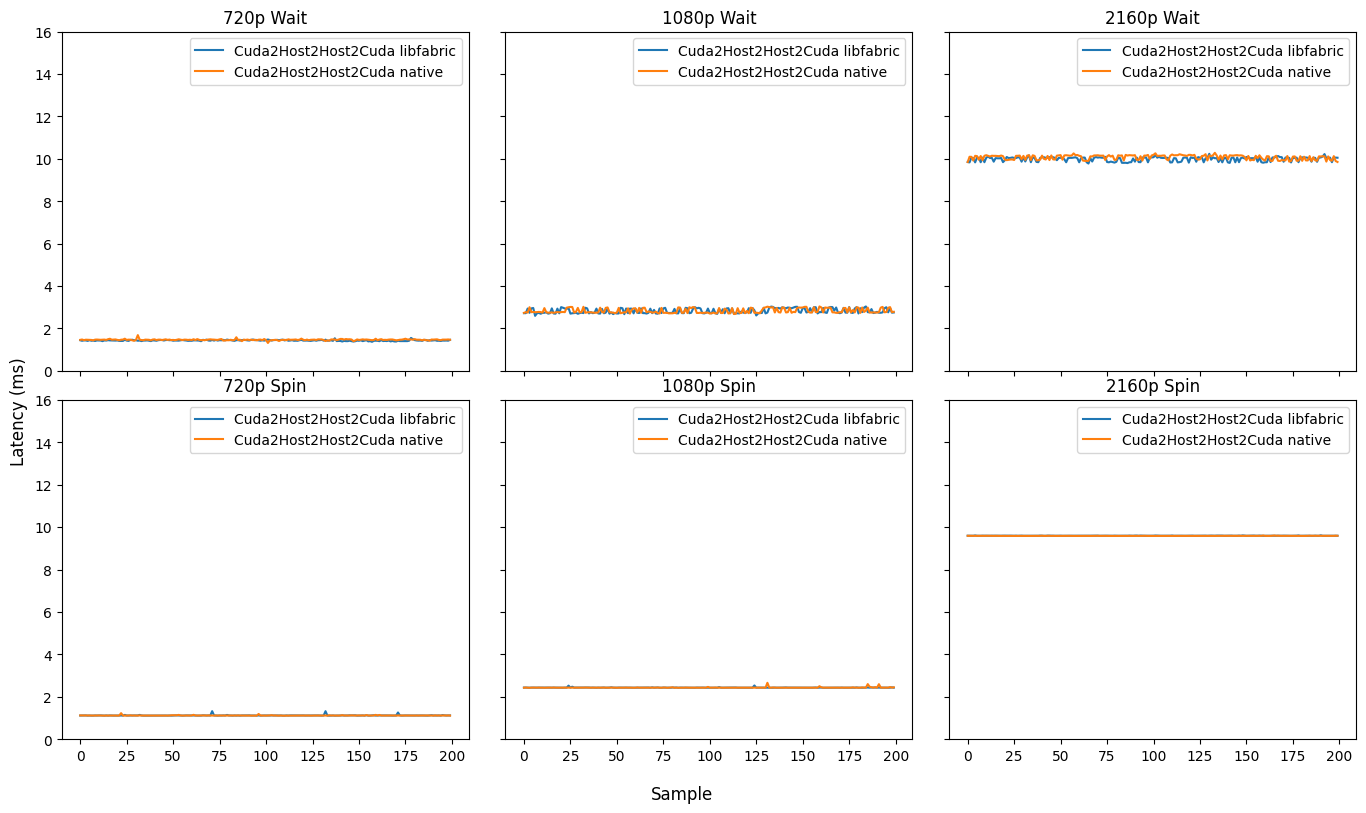

In [48]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(kwargs["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(kwargs["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in Library:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

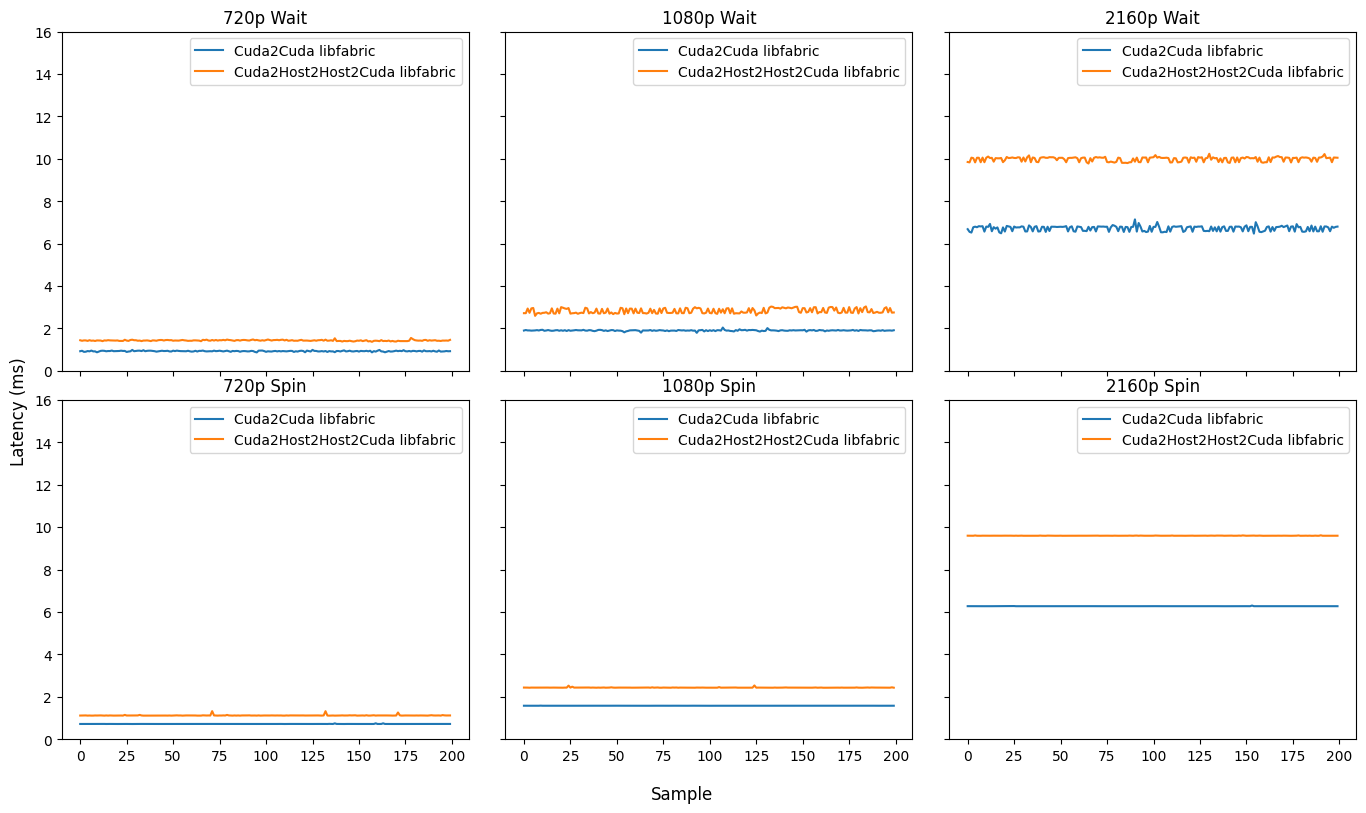

In [49]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(kwargs["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.libfabric

for i, format in enumerate(Format):
    for j, comp in enumerate(kwargs["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in kwargs["movements"]:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

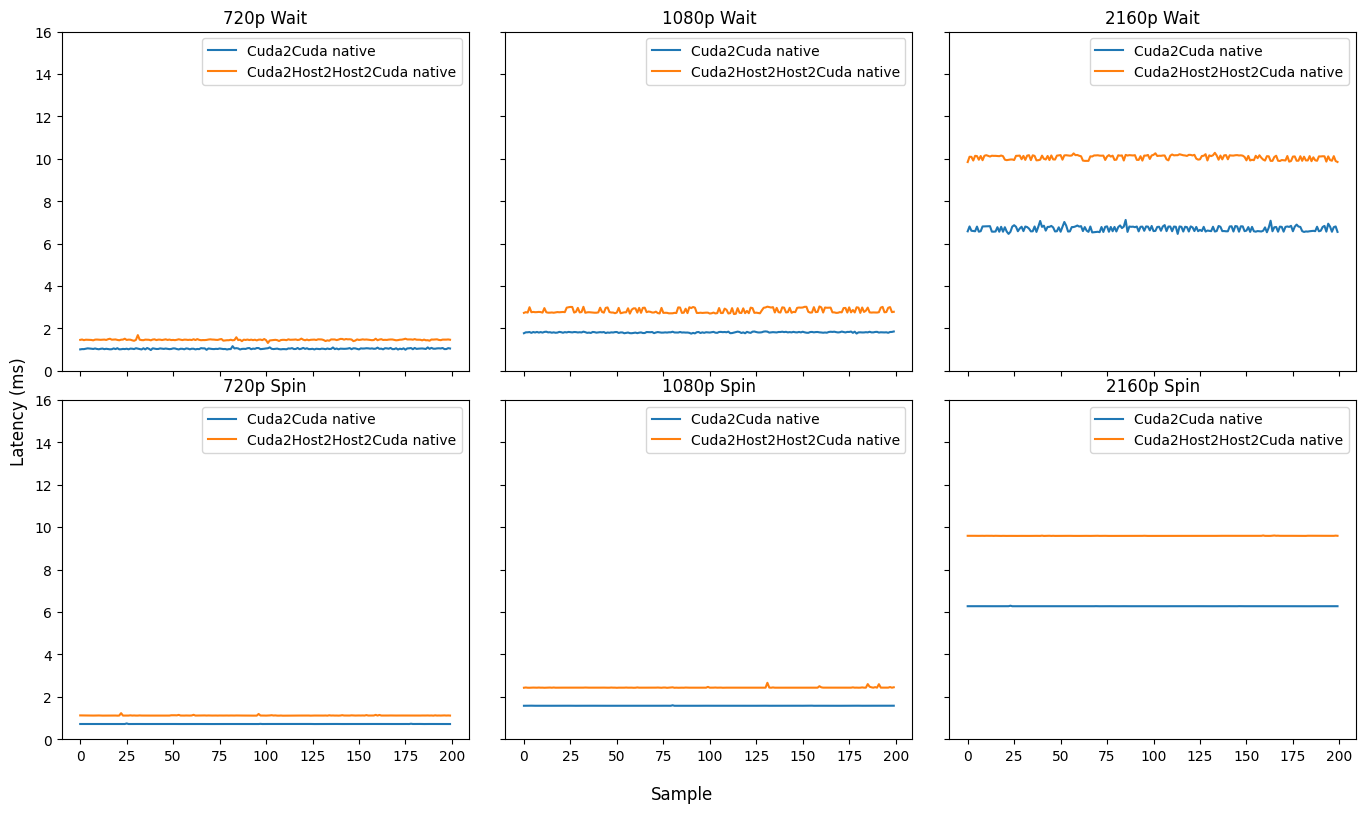

In [50]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(kwargs["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.native

for i, format in enumerate(Format):
    for j, comp in enumerate(kwargs["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in kwargs["movements"]:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

In [51]:
columns = ["library","format", "movement", "completion"]
dh2hd_interhost_table = make_table(data_dh2hd_interhost, columns=columns)

dh2hd_interhost_table
(
    dh2hd_interhost_table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=columns
    )
    .tab_spanner(
        label="Latency Measurements (ms)",
        columns=["mean", "max", "std"]
    )
)


GT(_tbl_data=shape: (24, 7)
┌───────────┬────────┬─────────────────────┬────────────┬─────────┬─────────┬────────┐
│ library   ┆ format ┆ movement            ┆ completion ┆ mean    ┆ max     ┆ std    │
│ ---       ┆ ---    ┆ ---                 ┆ ---        ┆ ---     ┆ ---     ┆ ---    │
│ enum      ┆ enum   ┆ enum                ┆ enum       ┆ f64     ┆ f64     ┆ f64    │
╞═══════════╪════════╪═════════════════════╪════════════╪═════════╪═════════╪════════╡
│ libfabric ┆ 720    ┆ Cuda2Cuda           ┆ Wait       ┆ 0.9306  ┆ 0.9906  ┆ 0.0199 │
│ libfabric ┆ 720    ┆ Cuda2Cuda           ┆ Spin       ┆ 0.7223  ┆ 0.753   ┆ 0.0038 │
│ native    ┆ 720    ┆ Cuda2Cuda           ┆ Wait       ┆ 1.0444  ┆ 1.1648  ┆ 0.0226 │
│ native    ┆ 720    ┆ Cuda2Cuda           ┆ Spin       ┆ 0.7202  ┆ 0.746   ┆ 0.0023 │
│ libfabric ┆ 720    ┆ Cuda2Host2Host2Cuda ┆ Wait       ┆ 1.4335  ┆ 1.5535  ┆ 0.0237 │
│ …         ┆ …      ┆ …                   ┆ …          ┆ …       ┆ …       ┆ …      │
│ native    ┆ 2160   ┆ Cuda2Cuda           ┆ Spin       ┆ 6.2731  ┆ 6.2965  ┆ 0.0018 │
│ libfabric ┆ 2160   ┆ Cuda2Host2Host2Cuda ┆ Wait       ┆ 9.9894  ┆ 10.2355 ┆ 0.1033 │
│ libfabric ┆ 2160   ┆ Cuda2Host2Host2Cuda ┆ Spin       ┆ 9.5971  ┆ 9.6161  ┆ 0.0034 │
│ native    ┆ 2160   ┆ Cuda2Host2Host2Cuda ┆ Wait       ┆ 10.0705 ┆ 10.2803 ┆ 0.1083 │
│ native    ┆ 2160   ┆ Cuda2Host2Host2Cuda ┆ Spin       ┆ 9.5905  ┆ 9.6081  ┆ 0.0029 │
└───────────┴────────┴─────────────────────┴────────────┴─────────┴─────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x78cc64456910>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x78cc6c0f0e50>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'movement', 'completion'], built=None), SpannerInfo(spanner_id='Latency Measurements (ms)', spanner_level=0, spanner_label='Latency Measurements (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x78cc3de1d5d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', va

## Host to Device Intra-Host

In [52]:
kwargs = {"libraries": [Library.libfabric], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda]}
data_h2d_intrahost = load_data(f"../data/h2d-intrahost", diff_loader, **kwargs)

### Comparison libfabric vs native cuda for Host-to-Device transfers

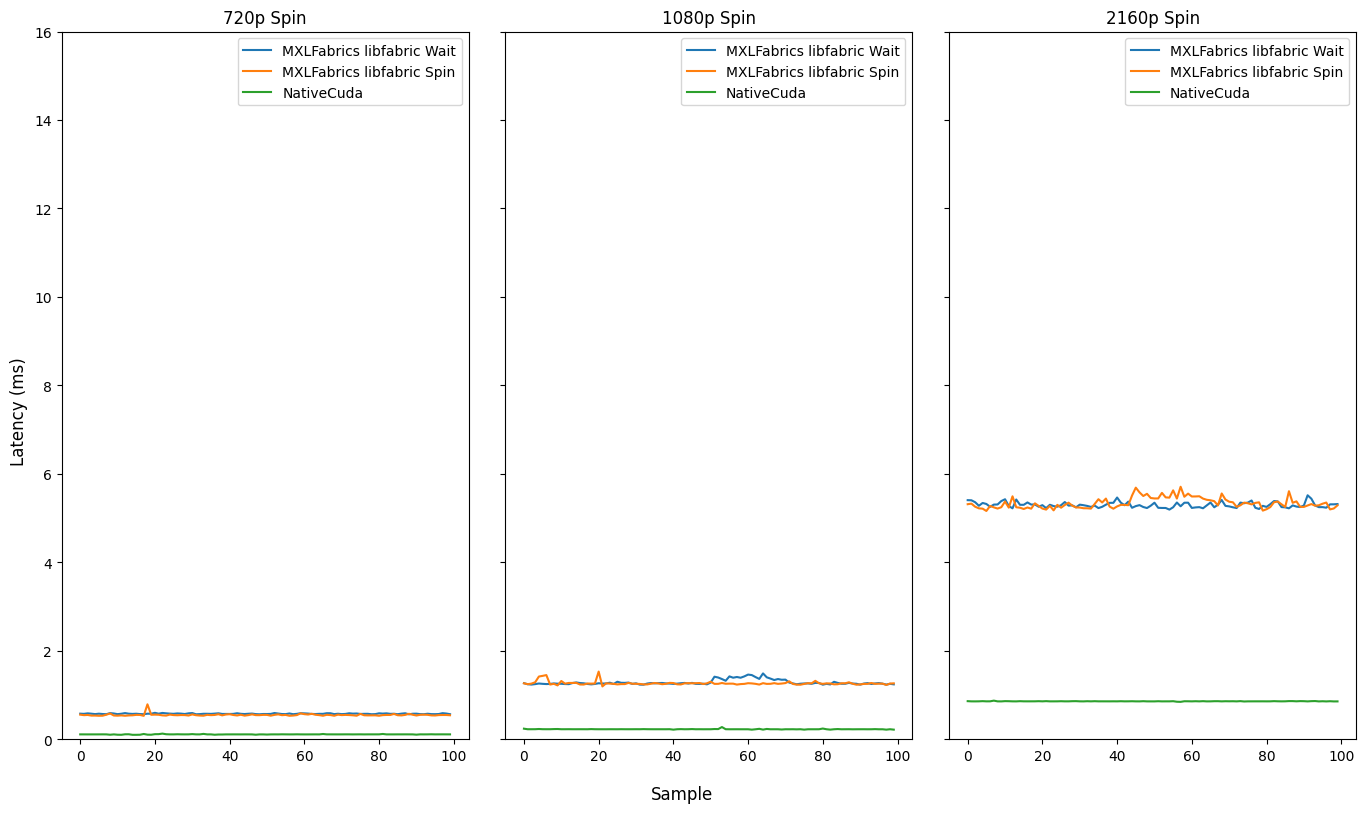

In [53]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in kwargs["completions"]:
        for library in kwargs["libraries"]:
            axs[i].plot(data_h2d_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"{Test.mxl_fabrics.value} {library.value} {comp.value}")
    axs[i].plot(data_h2d_intrahost[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p {comp.value}")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

In [54]:
columns = ["library","format", "completion", "test"]
h2d_intrahost_table = make_table(data_h2d_intrahost, columns=columns)

h2d_intrahost_table
(
    h2d_intrahost_table
    .tab_header(
        title="Host-to-Device transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=columns
    )
    .tab_spanner(
        label="Latency Measurements (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (9, 7)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.5771 ┆ 0.5981 ┆ 0.0079 │
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.5504 ┆ 0.7901 ┆ 0.0269 │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1106 ┆ 0.1283 ┆ 0.004  │
│ libfabric ┆ 1080   ┆ Wait       ┆ MXLFabrics ┆ 1.2866 ┆ 1.489  ┆ 0.0584 │
│ libfabric ┆ 1080   ┆ Spin       ┆ MXLFabrics ┆ 1.2659 ┆ 1.5304 ┆ 0.0442 │
│ native    ┆ 1080   ┆            ┆ NativeCuda ┆ 0.2275 ┆ 0.2762 ┆ 0.0061 │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 5.2978 ┆ 5.5157 ┆ 0.0621 │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 5.3408 ┆ 5.7086 ┆ 0.1217 │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.8586 ┆ 0.8734 ┆ 0.003  │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x78cc6c11b850>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x78cc64287810>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='Latency Measurements (ms)', spanner_level=0, spanner_label='Latency Measurements (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x78cc644fad50>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category=

## Device to Host Intra-Host

In [55]:
kwargs = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda]}
data_d2h_intrahost = load_data(f"../data/d2h-intrahost", diff_loader, **kwargs)

### Comparison libfabric vs native cuda for Device-to-Host transfers

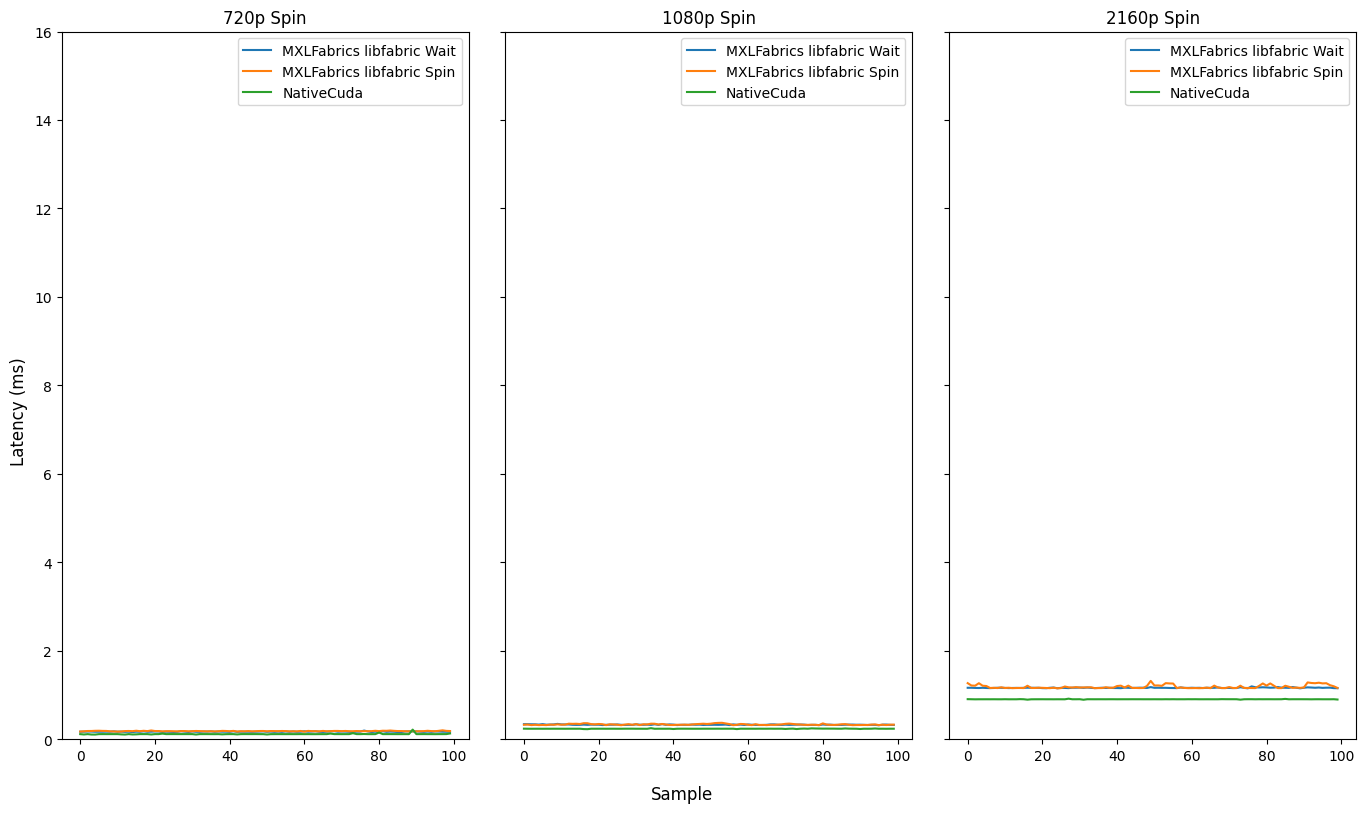

In [56]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in kwargs["completions"]:
        for library in kwargs["libraries"]:
            axs[i].plot(data_d2h_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"{Test.mxl_fabrics.value} {library.value} {comp.value}")
    axs[i].plot(data_d2h_intrahost[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p {comp.value}")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

In [57]:
columns = ["library","format", "completion", "test"]
d2h_intrahost_table = make_table(data_d2h_intrahost, columns=columns)

d2h_intrahost_table
(
    d2h_intrahost_table
    .tab_header(
        title="Host-to-Device transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=columns
    )
    .tab_spanner(
        label="Latency Measurements (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (9, 7)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.1725 ┆ 0.1967 ┆ 0.005  │
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.1845 ┆ 0.2021 ┆ 0.0052 │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1176 ┆ 0.219  ┆ 0.0116 │
│ libfabric ┆ 1080   ┆ Wait       ┆ MXLFabrics ┆ 0.3293 ┆ 0.3478 ┆ 0.0054 │
│ libfabric ┆ 1080   ┆ Spin       ┆ MXLFabrics ┆ 0.3351 ┆ 0.3723 ┆ 0.0125 │
│ native    ┆ 1080   ┆            ┆ NativeCuda ┆ 0.2385 ┆ 0.2515 ┆ 0.0028 │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 1.1638 ┆ 1.1965 ┆ 0.0066 │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 1.188  ┆ 1.3195 ┆ 0.0397 │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.9046 ┆ 0.9177 ┆ 0.0025 │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x78cc64113410>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x78cc3df158d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='Latency Measurements (ms)', spanner_level=0, spanner_label='Latency Measurements (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x78cc6c0bfad0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category=

## Device to Device Intra-host Inter-GPU